# Refactoring Quality Prediction using Machine Learning

This notebook builds ML **regression** models to predict the **continuous quality score** (0–6) of code refactoring produced by 5 LLM models:
- **Claude Opus**
- **Claude Sonnet 4.6**
- **Gemini 3.1 Pro**
- **Gemini Flash**
- **GPT-OSS (120B)**

Since every LLM improves code quality to some degree, the goal is not to classify "good vs bad" but to **quantify how much each LLM improves quality** and rank them accordingly.


## 1. Import Libraries and Load Datasets

In [1]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)
import seaborn as sns

from sklearn.model_selection import (train_test_split, KFold, cross_val_score,
                                      GridSearchCV, LeaveOneGroupOut, GroupShuffleSplit)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline as _Pipeline
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)

# Try importing XGBoost
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print("XGBoost available.")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available. Using GradientBoostingRegressor instead.")

# Try importing SHAP
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP available.")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available. Skipping SHAP analysis.")

DATASET_DIR = 'dataset'

# ── Output directory for all plots ───────────────────────────────────────────
PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Plots will be saved to: {os.path.abspath(PLOTS_DIR)}/")

# Load datasets
df_original      = pd.read_csv(f'{DATASET_DIR}/original_data.csv')
df_claude_opus   = pd.read_csv(f'{DATASET_DIR}/claude_opus.csv')
df_claude_sonnet = pd.read_csv(f'{DATASET_DIR}/claude_sonnet_4_6.csv')
df_gemini_pro    = pd.read_csv(f'{DATASET_DIR}/gemini_3_1_pro.csv')
df_gemini_flash  = pd.read_csv(f'{DATASET_DIR}/gemini_flash.csv')
df_gpt_oss       = pd.read_csv(f'{DATASET_DIR}/gpt_oss.csv')

print("Dataset shapes:")
print(f"  Original data:      {df_original.shape}")
print(f"  Claude Opus:        {df_claude_opus.shape}")
print(f"  Claude Sonnet 4.6:  {df_claude_sonnet.shape}")
print(f"  Gemini 3.1 Pro:     {df_gemini_pro.shape}")
print(f"  Gemini Flash:       {df_gemini_flash.shape}")
print(f"  GPT-OSS:            {df_gpt_oss.shape}")

print("\nOriginal data columns:", df_original.columns.tolist())
print("Claude Opus columns:  ", df_claude_opus.columns.tolist())


XGBoost not available. Using GradientBoostingRegressor instead.
SHAP not available. Skipping SHAP analysis.
Plots will be saved to: C:\Users\prart\OneDrive\Desktop\Research_Project\code\codeworks\plots/
Dataset shapes:
  Original data:      (1516, 6)
  Claude Opus:        (1200, 9)
  Claude Sonnet 4.6:  (1200, 9)
  Gemini 3.1 Pro:     (1200, 8)
  Gemini Flash:       (1200, 8)
  GPT-OSS:            (1200, 9)

Original data columns: ['Repository Link', 'File name', 'Function name', 'code_section', 'Approximate Number of Lines', 'Long Method']
Claude Opus columns:   ['Repository Link', 'File name', 'Function name', 'code_section', 'Approximate Number of Lines', 'Long Method', 'refactor', 'generation_time_ms', 'total_tokens']


## 2. Data Merging and Preprocessing

In [2]:
MERGE_KEYS = ['Repository Link', 'File name', 'Function name']

def prepare_model_df(df, model_name, orig_df):
    """Normalize and add model column; extract refactored code from right column."""
    df = df.copy()
    df['model'] = model_name

    # Some files (gemini) embed refactored code in 'code_section', others use 'refactor' column
    if 'refactor' in df.columns:
        df['refactored_code'] = df['refactor'].astype(str)
    else:
        # For gemini files the refactored code IS the code_section (already replaced)
        # We'll compare against the original code_section
        df['refactored_code'] = df['code_section'].astype(str)

    # Keep only needed columns
    keep_cols = MERGE_KEYS + ['Approximate Number of Lines', 'Long Method', 'model', 'refactored_code']
    df = df[[c for c in keep_cols if c in df.columns]]
    return df

# Add original code_section to original df for comparison
orig_ref = df_original[MERGE_KEYS + ['code_section', 'Approximate Number of Lines', 'Long Method']].copy()
orig_ref.columns = MERGE_KEYS + ['original_code', 'orig_lines', 'orig_long_method']

# Build per-model dataframes
model_dfs = {
    'claude_opus':       prepare_model_df(df_claude_opus,   'claude_opus',   df_original),
    'claude_sonnet_4_6': prepare_model_df(df_claude_sonnet, 'claude_sonnet_4_6', df_original),
    'gemini_3_1_pro':    prepare_model_df(df_gemini_pro,    'gemini_3_1_pro', df_original),
    'gemini_flash':      prepare_model_df(df_gemini_flash,  'gemini_flash',   df_original),
    'gpt_oss':           prepare_model_df(df_gpt_oss,       'gpt_oss',        df_original),
}

# Merge each model df with original
merged_list = []
for model_name, mdf in model_dfs.items():
    merged = mdf.merge(orig_ref, on=MERGE_KEYS, how='inner')
    merged_list.append(merged)

df_all = pd.concat(merged_list, ignore_index=True)

# Standardize Long Method column to binary
df_all['long_method'] = df_all['Long Method'].str.strip().str.lower().map({'yes': 1, 'no': 0}).fillna(0).astype(int)

# Drop rows where refactored_code is null/NaN/empty
df_all = df_all[df_all['refactored_code'].notna() & (df_all['refactored_code'].str.strip() != '')]
df_all = df_all.dropna(subset=['orig_lines'])
df_all = df_all.drop_duplicates(subset=MERGE_KEYS + ['model'])
df_all = df_all.reset_index(drop=True)

print(f"Total merged records: {len(df_all)}")
print(f"Per model counts:\n{df_all['model'].value_counts()}")
df_all.head(3)

Total merged records: 2710
Per model counts:
model
claude_opus          542
claude_sonnet_4_6    542
gemini_3_1_pro       542
gemini_flash         542
gpt_oss              542
Name: count, dtype: int64


,Repository Link,File name,Function name,Approximate Number of Lines,Long Method,model,refactored_code,original_code,orig_lines,orig_long_method,long_method
0,https://github.com/public-apis/public-apis.git,scripts/tests/test_validate_format.py,test_error_message_return_and_return_type,18.0,No,claude_opus,from __future__ import annotations\r\ndef test...,def test_error_message_return_and_return_type(...,18.0,No,0
1,https://github.com/public-apis/public-apis.git,scripts/tests/test_validate_format.py,test_if_get_categories_content_return_correct_...,23.0,No,claude_opus,from __future__ import annotations\r\ndef test...,def test_if_get_categories_content_return_corr...,23.0,No,0
2,https://github.com/public-apis/public-apis.git,scripts/tests/test_validate_format.py,test_if_check_alphabetical_order_return_correc...,40.0,Yes,claude_opus,from __future__ import annotations\r\ndef test...,def test_if_check_alphabetical_order_return_co...,40.0,Yes,1


## 3. Feature Engineering & Code Smell Detection

We extract two layers of features:
- **Structural features** – line counts, complexity proxies, naming patterns
- **Code smell features** – 9 smell detectors applied to both original and refactored code

The smell reduction (original smells − refactored smells) is the primary signal that an LLM actually improved the code.


In [3]:
import re

# ─────────────────────────────────────────────────────────────────────────────
# 3A.  Basic structural helpers
# ─────────────────────────────────────────────────────────────────────────────

def count_code_lines(code_str):
    """Count non-empty lines in a code string."""
    if not isinstance(code_str, str):
        return 0
    return len([l for l in code_str.replace('\\n', '\n').split('\n') if l.strip()])

def count_keywords(code_str, keywords=('if ', 'for ', 'while ', 'try:', 'except', 'with ')):
    """Proxy for cyclomatic complexity via keyword count."""
    if not isinstance(code_str, str):
        return 0
    return sum(code_str.count(kw) for kw in keywords)

def has_future_import(code_str):
    return int(isinstance(code_str, str) and 'from __future__ import annotations' in code_str)

def has_docstring(code_str):
    return int(isinstance(code_str, str) and ('"""' in code_str or "'''" in code_str))

def has_type_hints(code_str):
    if not isinstance(code_str, str):
        return 0
    return int(bool(re.search(
        r'->\s*(str|int|float|bool|None|list|dict|tuple|Any|Optional|List|Dict|Tuple)',
        code_str)))

# ─────────────────────────────────────────────────────────────────────────────
# 3B.  Code Smell Detectors  (9 smells, each returns 0 or 1)
# ─────────────────────────────────────────────────────────────────────────────

SMELL_NAMES = [
    'long_method',      # function body > 20 non-empty lines
    'long_param_list',  # > 4 parameters (excl. self/cls)
    'deep_nesting',     # max indentation ≥ 4 levels (16 spaces)
    'magic_numbers',    # bare numeric literals beyond 0,1,2,-1
    'no_docstring',     # missing docstring
    'no_type_hints',    # no return / param type annotations
    'long_lines',       # any line > 79 chars
    'commented_code',   # commented-out executable code
    'poor_naming',      # single-char variable assignments
]

def detect_code_smells(code_str):
    """Return {smell_name: 0/1} for all 9 smells."""
    empty = {s: 0 for s in SMELL_NAMES}
    if not isinstance(code_str, str) or len(code_str.strip()) < 5:
        return empty

    code     = code_str.replace('\\n', '\n')
    lines    = code.split('\n')
    nonempty = [l for l in lines if l.strip()]
    smells   = {}

    # 1. Long Method
    smells['long_method'] = int(len(nonempty) > 20)

    # 2. Long Parameter List
    sig = re.search(r'def\s+\w+\s*\(([^)]*)\)', code)
    if sig:
        params = [p.strip() for p in sig.group(1).split(',')
                  if p.strip() and p.strip() not in ('self', 'cls')]
        smells['long_param_list'] = int(len(params) > 4)
    else:
        smells['long_param_list'] = 0

    # 3. Deep Nesting (≥ 4 indent levels × 4 spaces = 16 spaces)
    max_indent = max((len(l) - len(l.lstrip())) for l in nonempty) if nonempty else 0
    smells['deep_nesting'] = int(max_indent >= 16)

    # 4. Magic Numbers (ignore 0,1,2,3,-1 and common constants)
    _allowed_nums = {'0', '1', '2', '3', '10', '100', '-1', '0.0', '1.0'}
    nums  = re.findall(r'(?<!\w)(\d+\.?\d*)(?!\w)', code)
    magic = [n for n in nums if n not in _allowed_nums]
    smells['magic_numbers'] = int(len(magic) > 2)

    # 5. No Docstring
    smells['no_docstring'] = int('"""' not in code and "'''" not in code)

    # 6. No Type Hints
    smells['no_type_hints'] = int(not bool(re.search(
        r'->\s*\w|:\s*(str|int|float|bool|None|list|dict|tuple|Any|Optional|List|Dict|Tuple)',
        code)))

    # 7. Long Lines
    smells['long_lines'] = int(any(len(l) > 79 for l in lines))

    # 8. Commented-out Code (comment lines that look like executable code)
    commented = [l for l in lines if re.match(
        r'\s*#\s*(if |for |while |return |self\.|import |def |class |print\()', l)]
    smells['commented_code'] = int(len(commented) >= 1)

    # 9. Poor Naming (single-char variable assignments outside common loop vars)
    _allowed_vars = {'i', 'j', 'k', 'n', 'x', 'y', 'z', 'f', 'e', 'v', '_', 's', 'c', 'p', 'q'}
    poor = [v for v in re.findall(r'\b([a-zA-Z])\s*(?:\+|-|\*|\/)?=(?!=)', code)
            if v.lower() not in _allowed_vars]
    smells['poor_naming'] = int(len(poor) > 1)

    return smells

def count_smells(code_str):
    return sum(detect_code_smells(code_str).values())

# ─────────────────────────────────────────────────────────────────────────────
# 3C.  Build df_feat with all structural + smell features
# ─────────────────────────────────────────────────────────────────────────────

df_feat = df_all.copy()

# --- Original code structural features ---
df_feat['orig_line_count']   = df_feat['orig_lines'].fillna(0).astype(float)
df_feat['long_method_flag']  = df_feat['long_method']

# --- Refactored code structural features ---
df_feat['refact_line_count'] = df_feat['refactored_code'].apply(count_code_lines)
df_feat['line_delta']        = df_feat['orig_line_count'] - df_feat['refact_line_count']
df_feat['line_delta_ratio']  = df_feat['line_delta'] / (df_feat['orig_line_count'] + 1)

df_feat['has_future_import'] = df_feat['refactored_code'].apply(has_future_import)
df_feat['has_docstring']     = df_feat['refactored_code'].apply(has_docstring)
df_feat['has_type_hints']    = df_feat['refactored_code'].apply(has_type_hints)
df_feat['complexity_proxy']  = df_feat['refactored_code'].apply(count_keywords)
df_feat['orig_complexity']   = df_feat['original_code'].apply(count_keywords)
df_feat['complexity_delta']  = df_feat['orig_complexity'] - df_feat['complexity_proxy']

# --- Function name features ---
df_feat['func_name_len'] = df_feat['Function name'].apply(lambda x: len(str(x)))
df_feat['is_private']    = df_feat['Function name'].apply(lambda x: int(str(x).startswith('_') and not str(x).startswith('__')))
df_feat['is_dunder']     = df_feat['Function name'].apply(lambda x: int(str(x).startswith('__') and str(x).endswith('__')))
df_feat['is_test_func']  = df_feat['Function name'].apply(lambda x: int(str(x).startswith('test')))

# --- File/repo context features ---
df_feat['repo_avg_lines'] = df_feat.groupby('Repository Link')['orig_line_count'].transform('mean')
df_feat['file_avg_lines'] = df_feat.groupby('File name')['orig_line_count'].transform('mean')

global_max = df_feat['orig_line_count'].max()
df_feat['norm_line_count'] = df_feat['orig_line_count'] / (global_max + 1)

# --- Model encoding ---
le_model = LabelEncoder()
df_feat['model_enc'] = le_model.fit_transform(df_feat['model'])

# ─────────────────────────────────────────────────────────────────────────────
# 3D.  Apply smell detection to original AND refactored code
# ─────────────────────────────────────────────────────────────────────────────

print("Detecting code smells (this may take a moment)...")
orig_smell_dicts   = df_feat['original_code'].apply(detect_code_smells)
refact_smell_dicts = df_feat['refactored_code'].apply(detect_code_smells)

# Per-smell binary columns
for s in SMELL_NAMES:
    df_feat[f'orig_{s}']   = orig_smell_dicts.apply(lambda d: d[s])
    df_feat[f'refact_{s}'] = refact_smell_dicts.apply(lambda d: d[s])
    df_feat[f'fixed_{s}']  = (df_feat[f'orig_{s}'] - df_feat[f'refact_{s}']).clip(lower=0)

# Aggregate smell counts
df_feat['orig_smell_count']      = df_feat['original_code'].apply(count_smells)
df_feat['refact_smell_count']    = df_feat['refactored_code'].apply(count_smells)
df_feat['smell_reduction']       = (df_feat['orig_smell_count'] - df_feat['refact_smell_count']).clip(lower=0)
df_feat['smell_reduction_ratio'] = df_feat['smell_reduction'] / (df_feat['orig_smell_count'] + 1)

print(f"\n{'─'*50}")
print(f"  Code Smell Summary")
print(f"{'─'*50}")
print(f"  Avg smells in ORIGINAL code:    {df_feat['orig_smell_count'].mean():.2f} / {len(SMELL_NAMES)}")
print(f"  Avg smells in REFACTORED code:  {df_feat['refact_smell_count'].mean():.2f} / {len(SMELL_NAMES)}")
print(f"  Avg smell reduction:            {df_feat['smell_reduction'].mean():.2f}")
print(f"\n  Per-smell prevalence (original → refactored):")
for s in SMELL_NAMES:
    o = df_feat[f'orig_{s}'].mean() * 100
    r = df_feat[f'refact_{s}'].mean() * 100
    arrow = '↓' if r < o else ('↑' if r > o else '→')
    print(f"    {s:<22}: {o:5.1f}%  {arrow}  {r:5.1f}%")


Detecting code smells (this may take a moment)...

──────────────────────────────────────────────────
  Code Smell Summary
──────────────────────────────────────────────────
  Avg smells in ORIGINAL code:    3.17 / 9
  Avg smells in REFACTORED code:  2.98 / 9
  Avg smell reduction:            0.20

  Per-smell prevalence (original → refactored):
    long_method           :  57.9%  ↑   58.9%
    long_param_list       :   9.4%  ↑   10.4%
    deep_nesting          :  54.6%  ↓   54.3%
    magic_numbers         :  26.8%  ↑   27.2%
    no_docstring          :  54.2%  ↓   42.7%
    no_type_hints         :  43.2%  ↓   34.1%
    long_lines            :  68.1%  ↓   67.8%
    commented_code        :   0.7%  ↓    0.7%
    poor_naming           :   2.2%  ↑    2.3%


## 4. Exploratory Data Analysis (EDA)

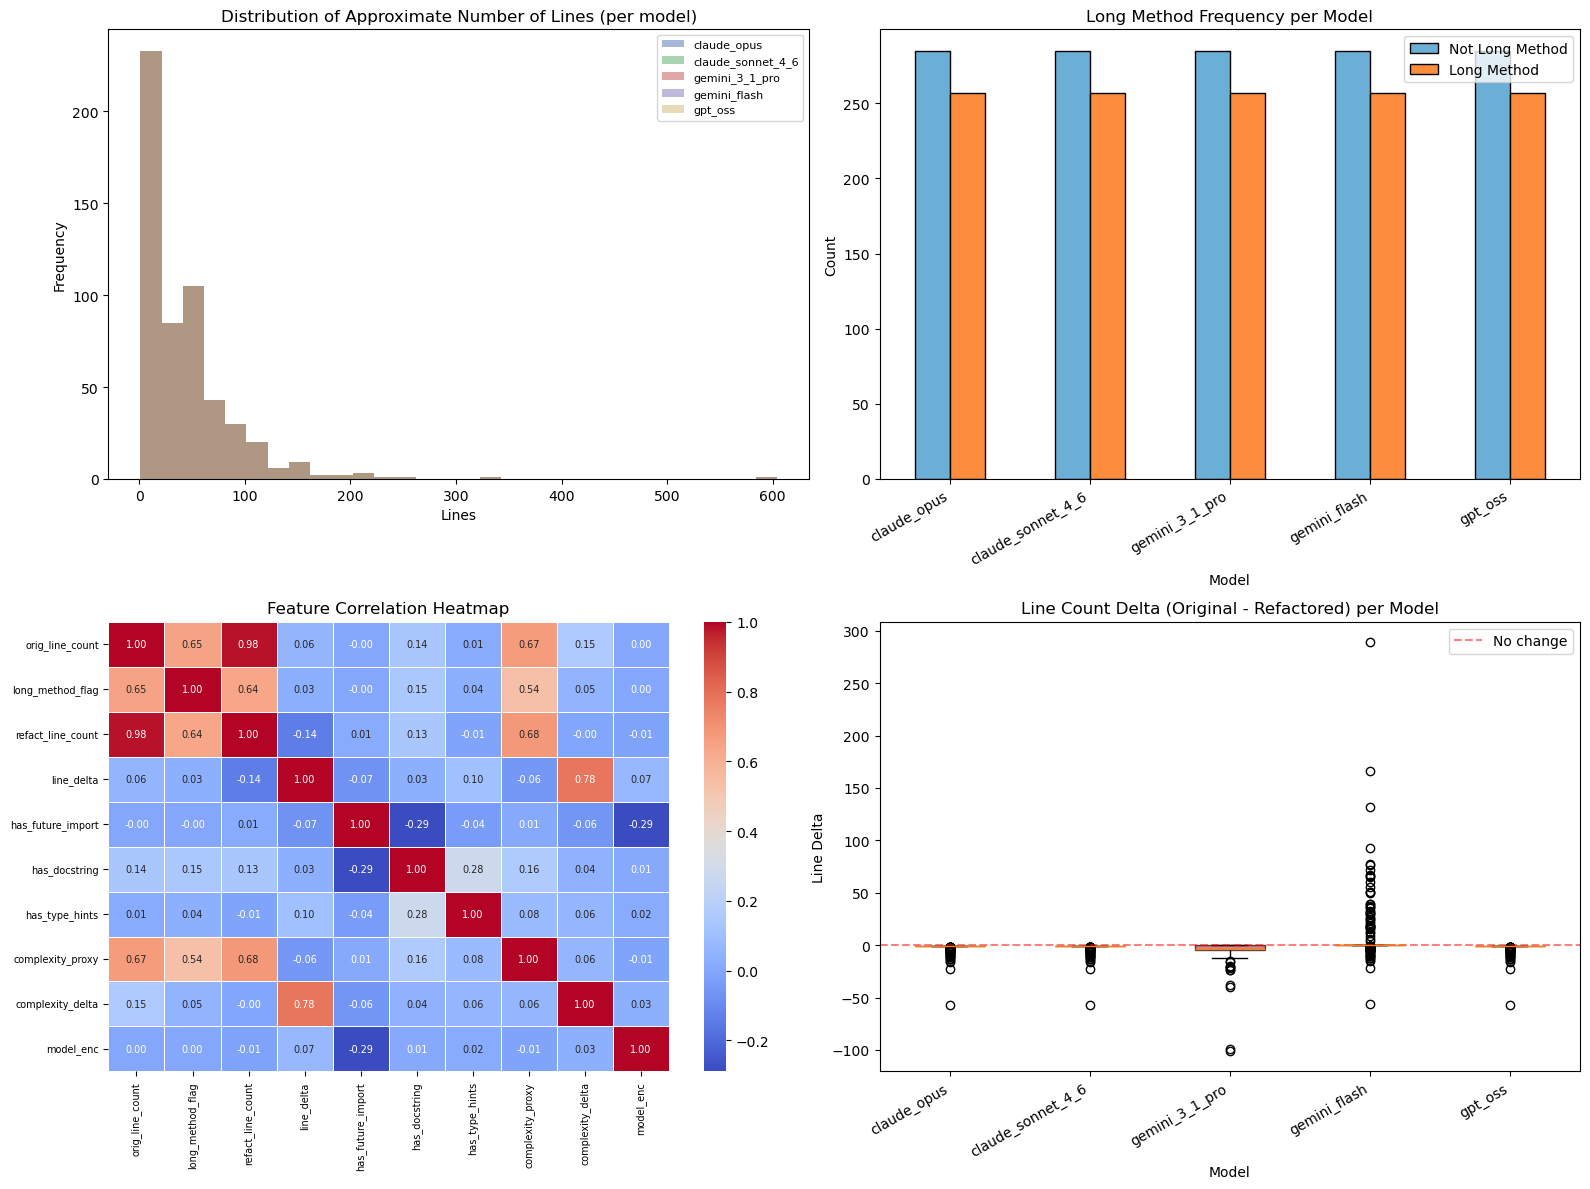

EDA plots saved.


In [4]:

MODEL_COLORS = {
    'claude_opus': '#4C72B0',
    'claude_sonnet_4_6': '#55A868',
    'gemini_3_1_pro': '#C44E52',
    'gemini_flash': '#8172B2',
    'gpt_oss': '#CCB974',
}
MODEL_ORDER = ['claude_opus', 'claude_sonnet_4_6', 'gemini_3_1_pro', 'gemini_flash', 'gpt_oss']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of orig_line_count per model
ax = axes[0, 0]
for model in MODEL_ORDER:
    subset = df_feat[df_feat['model'] == model]['orig_line_count']
    ax.hist(subset, bins=30, alpha=0.5, label=model, color=MODEL_COLORS[model])
ax.set_title('Distribution of Approximate Number of Lines (per model)')
ax.set_xlabel('Lines')
ax.set_ylabel('Frequency')
ax.legend(fontsize=8)

# 2. Long Method frequency per model
ax = axes[0, 1]
long_method_counts = df_feat.groupby(['model', 'long_method_flag']).size().unstack(fill_value=0)
long_method_counts.columns = ['Not Long Method', 'Long Method']
long_method_counts = long_method_counts.reindex(MODEL_ORDER)
long_method_counts.plot(kind='bar', ax=ax, color=['#6baed6', '#fd8d3c'], edgecolor='black')
ax.set_title('Long Method Frequency per Model')
ax.set_xlabel('Model')
ax.set_ylabel('Count')
ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
ax.legend()

# 3. Correlation heatmap
ax = axes[1, 0]
corr_cols = ['orig_line_count', 'long_method_flag', 'refact_line_count', 'line_delta',
             'has_future_import', 'has_docstring', 'has_type_hints',
             'complexity_proxy', 'complexity_delta', 'model_enc']
corr_matrix = df_feat[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            annot_kws={'size': 7}, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
ax.tick_params(axis='both', labelsize=7)

# 4. Refactored line count delta per model (boxplot)
ax = axes[1, 1]
model_data = [df_feat[df_feat['model'] == m]['line_delta'].dropna().values for m in MODEL_ORDER]
bp = ax.boxplot(model_data, patch_artist=True, labels=MODEL_ORDER)
for patch, model in zip(bp['boxes'], MODEL_ORDER):
    patch.set_facecolor(MODEL_COLORS[model])
    patch.set_alpha(0.7)
ax.set_title('Line Count Delta (Original - Refactored) per Model')
ax.set_xlabel('Model')
ax.set_ylabel('Line Delta')
ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
ax.axhline(0, color='red', linestyle='--', alpha=0.5, label='No change')
ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved.")


## 4b. Code Smell Analysis

Compare code smell prevalence in **original code vs LLM-refactored code** for each LLM model.  
A good refactoring tool should consistently reduce smells — this section quantifies that.


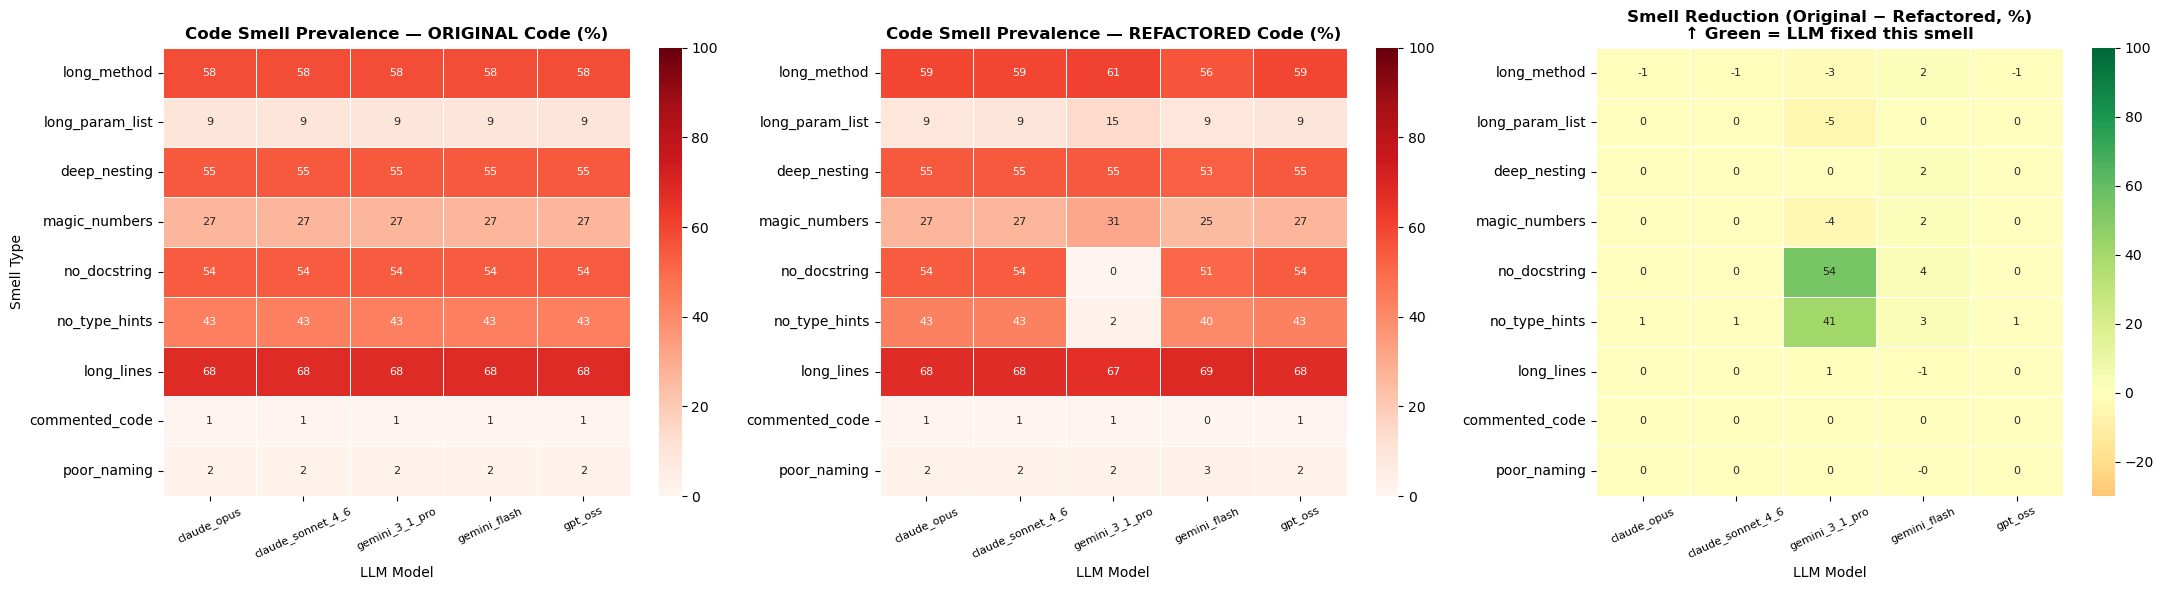

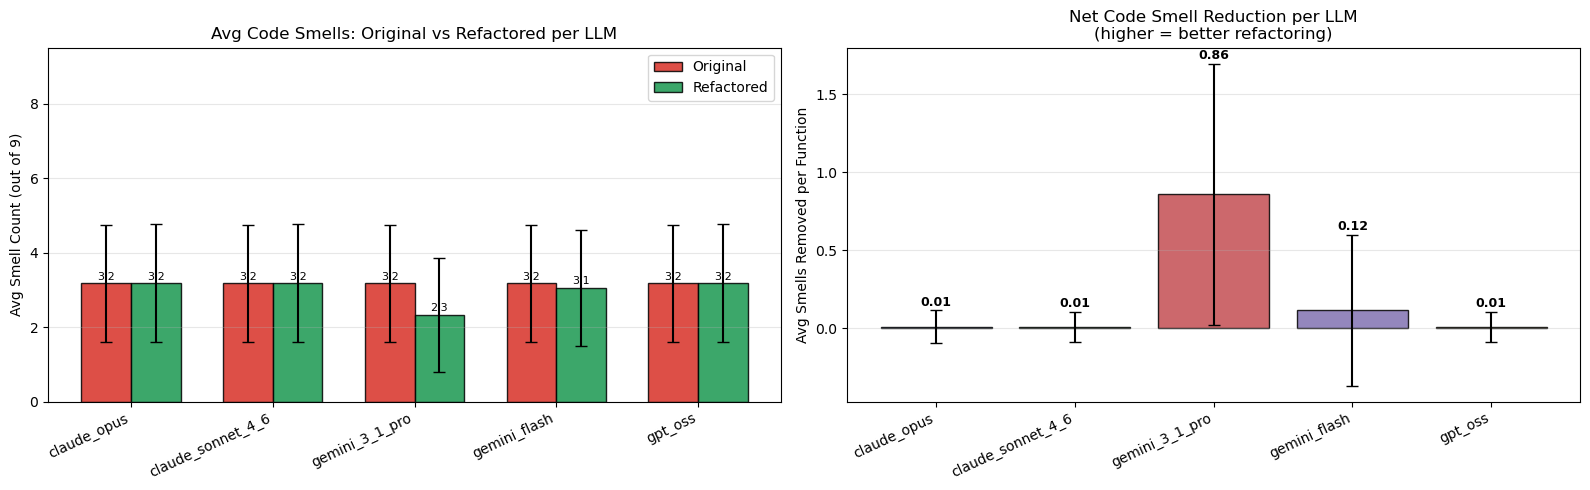

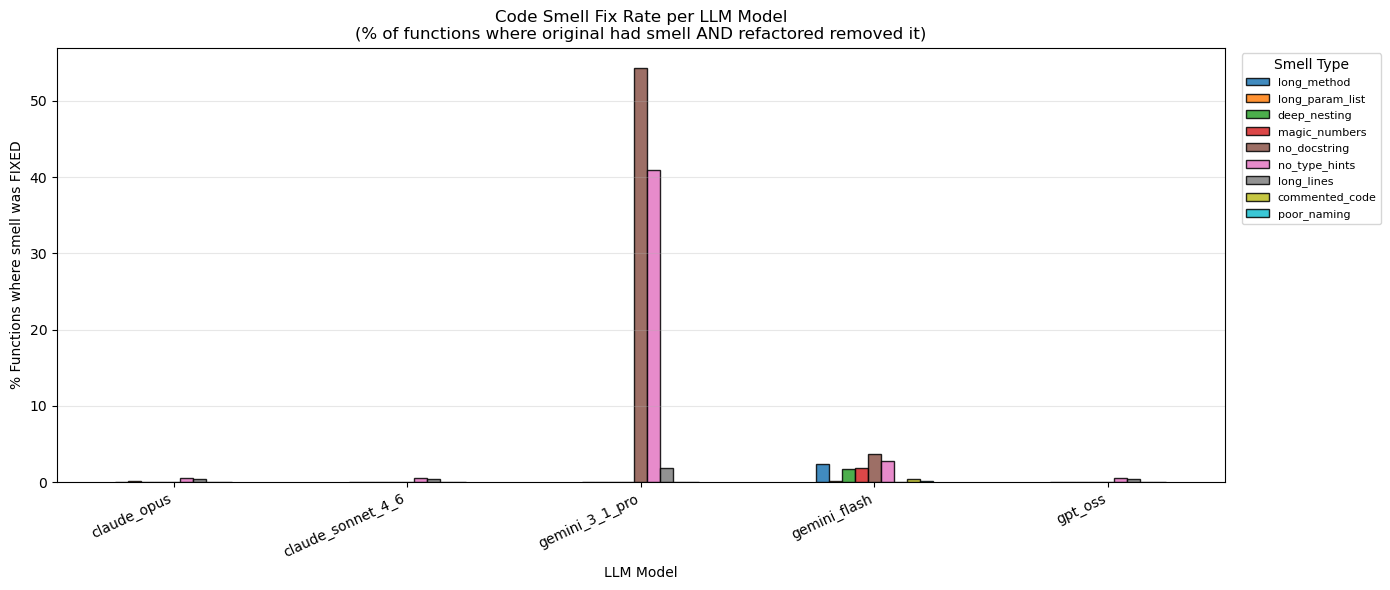

Code smell analysis plots saved.

Fix rate summary (% of functions where LLM removed the smell):
                 claude_opus  claude_sonnet_4_6  gemini_3_1_pro  gemini_flash  gpt_oss
long_method              0.0                0.0             0.0           2.4      0.0
long_param_list          0.2                0.0             0.0           0.2      0.0
deep_nesting             0.0                0.0             0.0           1.7      0.0
magic_numbers            0.0                0.0             0.0           1.8      0.0
no_docstring             0.0                0.0            54.2           3.7      0.0
no_type_hints            0.6                0.6            41.0           2.8      0.6
long_lines               0.4                0.4             1.8           0.0      0.4
commented_code           0.0                0.0             0.0           0.4      0.0
poor_naming              0.0                0.0             0.0           0.2      0.0


In [5]:

# ── 1. Overall smell reduction heatmap (per model × per smell) ───────────────
orig_smell_matrix   = pd.DataFrame({
    m: [df_feat[df_feat['model'] == m][f'orig_{s}'].mean() * 100 for s in SMELL_NAMES]
    for m in MODEL_ORDER
}, index=SMELL_NAMES)

refact_smell_matrix = pd.DataFrame({
    m: [df_feat[df_feat['model'] == m][f'refact_{s}'].mean() * 100 for s in SMELL_NAMES]
    for m in MODEL_ORDER
}, index=SMELL_NAMES)

reduction_matrix = orig_smell_matrix - refact_smell_matrix   # positive = improvement

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(orig_smell_matrix, annot=True, fmt='.0f', cmap='Reds',
            ax=axes[0], linewidths=0.5, annot_kws={'size': 8}, vmin=0, vmax=100)
axes[0].set_title('Code Smell Prevalence — ORIGINAL Code (%)', fontweight='bold')
axes[0].set_xlabel('LLM Model'); axes[0].set_ylabel('Smell Type')
axes[0].tick_params(axis='x', rotation=25, labelsize=8)

sns.heatmap(refact_smell_matrix, annot=True, fmt='.0f', cmap='Reds',
            ax=axes[1], linewidths=0.5, annot_kws={'size': 8}, vmin=0, vmax=100)
axes[1].set_title('Code Smell Prevalence — REFACTORED Code (%)', fontweight='bold')
axes[1].set_xlabel('LLM Model'); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=25, labelsize=8)

sns.heatmap(reduction_matrix, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=axes[2], linewidths=0.5, annot_kws={'size': 8},
            center=0, vmin=-30, vmax=100)
axes[2].set_title('Smell Reduction (Original − Refactored, %)\n↑ Green = LLM fixed this smell', fontweight='bold')
axes[2].set_xlabel('LLM Model'); axes[2].set_ylabel('')
axes[2].tick_params(axis='x', rotation=25, labelsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/smell_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Total smell count: Original vs Refactored per model ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x      = np.arange(len(MODEL_ORDER))
width  = 0.35
o_mean = [df_feat[df_feat['model'] == m]['orig_smell_count'].mean()   for m in MODEL_ORDER]
r_mean = [df_feat[df_feat['model'] == m]['refact_smell_count'].mean() for m in MODEL_ORDER]
o_std  = [df_feat[df_feat['model'] == m]['orig_smell_count'].std()    for m in MODEL_ORDER]
r_std  = [df_feat[df_feat['model'] == m]['refact_smell_count'].std()  for m in MODEL_ORDER]

axes[0].bar(x - width/2, o_mean, width, yerr=o_std, capsize=4,
            label='Original',    color='#d73027', alpha=0.85, edgecolor='black')
axes[0].bar(x + width/2, r_mean, width, yerr=r_std, capsize=4,
            label='Refactored',  color='#1a9850', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(MODEL_ORDER, rotation=25, ha='right')
axes[0].set_ylabel('Avg Smell Count (out of 9)')
axes[0].set_title('Avg Code Smells: Original vs Refactored per LLM')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3); axes[0].set_ylim(0, 9.5)
for i, (o, r) in enumerate(zip(o_mean, r_mean)):
    axes[0].text(i - width/2, o + 0.1, f'{o:.1f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, r + 0.1, f'{r:.1f}', ha='center', fontsize=8)

# Net smell reduction per model
red_mean = [df_feat[df_feat['model'] == m]['smell_reduction'].mean() for m in MODEL_ORDER]
red_std  = [df_feat[df_feat['model'] == m]['smell_reduction'].std()  for m in MODEL_ORDER]
colors   = [MODEL_COLORS[m] for m in MODEL_ORDER]
axes[1].bar(MODEL_ORDER, red_mean, yerr=red_std, capsize=4,
            color=colors, edgecolor='black', alpha=0.85)
axes[1].set_xticklabels(MODEL_ORDER, rotation=25, ha='right')
axes[1].set_ylabel('Avg Smells Removed per Function')
axes[1].set_title('Net Code Smell Reduction per LLM\n(higher = better refactoring)')
axes[1].grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(red_mean, red_std)):
    axes[1].text(i, m + s + 0.03, f'{m:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/smell_reduction_per_model.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Per-smell fix rate per LLM ────────────────────────────────────────────
fix_rates = pd.DataFrame({
    m: [df_feat[df_feat['model'] == m][f'fixed_{s}'].mean() * 100 for s in SMELL_NAMES]
    for m in MODEL_ORDER
}, index=SMELL_NAMES)

fig, ax = plt.subplots(figsize=(14, 6))
fix_rates.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='black', alpha=0.85)
ax.set_xlabel('LLM Model'); ax.set_ylabel('% Functions where smell was FIXED')
ax.set_title('Code Smell Fix Rate per LLM Model\n(% of functions where original had smell AND refactored removed it)')
ax.set_xticklabels(MODEL_ORDER, rotation=25, ha='right')
ax.legend(title='Smell Type', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/smell_fix_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print("Code smell analysis plots saved.")
print("\nFix rate summary (% of functions where LLM removed the smell):")
print(fix_rates.round(1).to_string())


## 5. Refactoring Quality Scoring (0–10 scale)

Quality is measured on a **meaningful 0–10 continuous scale** across three pillars:

| Pillar | Criterion | Points |
|--------|-----------|--------|
| **Code Presence** | Refactored code is non-empty | +1 |
| **Documentation** | Docstring present in refactored code | +1 |
| **Documentation** | Type hints present | +1 |
| **Modern Python** | `from __future__ import annotations` added | +1 |
| **Smell Removal** | Each code smell removed (capped at 5) | +0 to +5 |
| **Structural Improvement** | Line count reduced for long methods | +0.5 |
| **Structural Improvement** | Cyclomatic complexity reduced | +0.5 |

**Score interpretation:**
- `0–2` : Minimal improvement (output exists but no meaningful quality gains)
- `3–5` : Moderate improvement (some documentation or smells fixed)
- `6–8` : Good improvement (multiple smells removed + documentation)
- `9–10`: Excellent improvement (nearly all smells fixed + full documentation)


Quality Score Distribution (0–10 continuous scale):
quality_score
1.0     225
2.0    1007
3.0     901
3.5       4
4.0     537
4.5       4
5.0      20
5.5       2
6.0       6
7.0       4
Name: count, dtype: int64

Mean : 2.693
Std  : 0.943
Range: 1.0  –  7.0


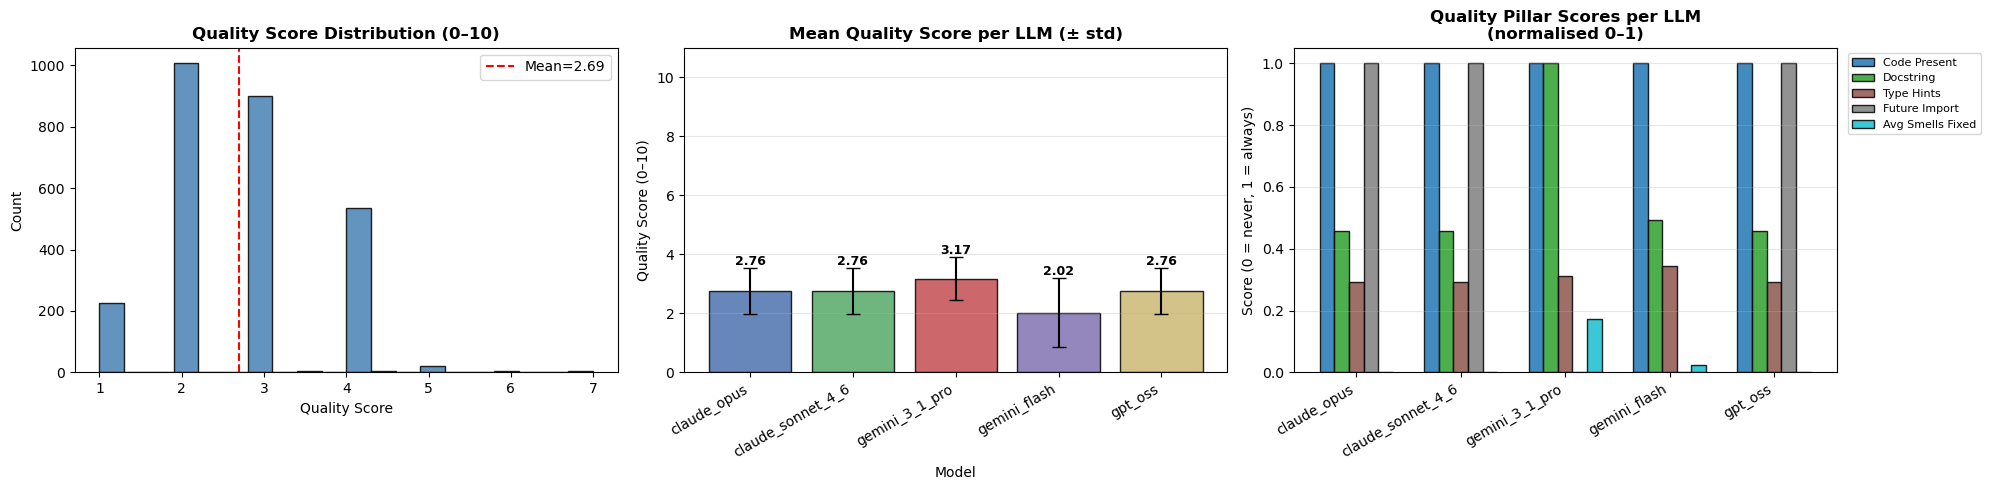


Per-model quality score summary:
                    mean    std  count
model                                 
claude_opus        2.760  0.787    542
claude_sonnet_4_6  2.758  0.785    542
gemini_3_1_pro     3.170  0.728    542
gemini_flash       2.017  1.171    542
gpt_oss            2.758  0.785    542


In [6]:

def compute_quality_score(row):
    """
    Compute a continuous quality improvement score (0–10).

    Pillars
    -------
    Code Presence      : 0–1   (is there actually a refactored version?)
    Documentation      : 0–2   (docstring + type hints)
    Modern Python      : 0–1   (future annotations)
    Smell Removal      : 0–5   (each smell removed counts as 1 point, max 5)
    Structural          : 0–1   (line reduction for long methods + complexity drop)
    """
    score = 0.0

    # ── Pillar 1: Code Presence (0–1) ────────────────────────────────────────
    if isinstance(row['refactored_code'], str) and len(row['refactored_code'].strip()) > 10:
        score += 1.0

    # ── Pillar 2: Documentation (0–2) ────────────────────────────────────────
    if row['has_docstring']:
        score += 1.0
    if row['has_type_hints']:
        score += 1.0

    # ── Pillar 3: Modern Python (0–1) ────────────────────────────────────────
    if row['has_future_import']:
        score += 1.0

    # ── Pillar 4: Code Smell Removal (0–5) ───────────────────────────────────
    # Each smell removed = +1 point, maximum contribution is 5
    smell_removed = max(0, row['orig_smell_count'] - row['refact_smell_count'])
    score += min(smell_removed, 5.0)

    # ── Pillar 5: Structural Improvement (0–1) ───────────────────────────────
    if row['long_method_flag'] == 1 and row['line_delta'] > 0:
        score += 0.5    # long method got shorter
    if row['complexity_delta'] > 0:
        score += 0.5    # cyclomatic complexity dropped

    return round(score, 1)   # 0.0 – 10.0

df_feat['quality_score'] = df_feat.apply(compute_quality_score, axis=1)

# ── Distribution summary ──────────────────────────────────────────────────────
print("Quality Score Distribution (0–10 continuous scale):")
print(df_feat['quality_score'].value_counts().sort_index())
print(f"\nMean : {df_feat['quality_score'].mean():.3f}")
print(f"Std  : {df_feat['quality_score'].std():.3f}")
print(f"Range: {df_feat['quality_score'].min():.1f}  –  {df_feat['quality_score'].max():.1f}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Score histogram
axes[0].hist(df_feat['quality_score'], bins=20, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Quality Score Distribution (0–10)', fontweight='bold')
axes[0].set_xlabel('Quality Score'); axes[0].set_ylabel('Count')
axes[0].axvline(df_feat['quality_score'].mean(), color='red', linestyle='--',
                label=f"Mean={df_feat['quality_score'].mean():.2f}")
axes[0].legend()

# Per-model mean score
model_quality = df_feat.groupby('model')['quality_score'].agg(['mean', 'std', 'count'])
model_quality = model_quality.reindex(MODEL_ORDER)
axes[1].bar(model_quality.index, model_quality['mean'],
            yerr=model_quality['std'], capsize=5,
            color=[MODEL_COLORS[m] for m in MODEL_ORDER], edgecolor='black', alpha=0.85)
axes[1].set_title('Mean Quality Score per LLM (± std)', fontweight='bold')
axes[1].set_xlabel('Model'); axes[1].set_ylabel('Quality Score (0–10)')
axes[1].set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
axes[1].set_ylim(0, 11)
axes[1].grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(model_quality['mean'], model_quality['std'])):
    axes[1].text(i, m + s + 0.1, f'{m:.2f}', ha='center', fontsize=9, fontweight='bold')

# Score pillar breakdown per model
pillars = {
    'Code Presence': 'has_code',
    'Docstring'     : 'has_docstring',
    'Type Hints'    : 'has_type_hints',
    'Future Import' : 'has_future_import',
    'Smell Removal' : 'smell_reduction',
}
# Build breakdown table
df_feat['has_code'] = (
    df_feat['refactored_code'].apply(lambda x: int(isinstance(x, str) and len(x.strip()) > 10)))
breakdown = {}
for m in MODEL_ORDER:
    sub = df_feat[df_feat['model'] == m]
    breakdown[m] = {
        'Code Present':   sub['has_code'].mean(),
        'Docstring':      sub['has_docstring'].mean(),
        'Type Hints':     sub['has_type_hints'].mean(),
        'Future Import':  sub['has_future_import'].mean(),
        'Avg Smells Fixed': sub['smell_reduction'].mean() / 5,   # normalised to 0-1
    }
bd_df = pd.DataFrame(breakdown).T
bd_df_plot = bd_df.copy()
bd_df_plot.columns = [c for c in bd_df.columns]
bd_df_plot.plot(kind='bar', ax=axes[2], colormap='tab10', edgecolor='black', alpha=0.85, width=0.7)
axes[2].set_title('Quality Pillar Scores per LLM\n(normalised 0–1)', fontweight='bold')
axes[2].set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
axes[2].set_ylabel('Score (0 = never, 1 = always)')
axes[2].legend(fontsize=8, bbox_to_anchor=(1.01, 1))
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/quality_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-model quality score summary:")
print(model_quality.round(3).to_string())


## 6. Train-Test Split and Cross-Validation Setup


In [7]:

# ── Structural features ───────────────────────────────────────────────────────
STRUCTURAL_FEATURES = [
    'orig_line_count', 'long_method_flag', 'refact_line_count', 'line_delta',
    'line_delta_ratio', 'has_future_import', 'has_docstring', 'has_type_hints',
    'complexity_proxy', 'orig_complexity', 'complexity_delta', 'func_name_len',
    'is_private', 'is_dunder', 'is_test_func', 'repo_avg_lines',
    'file_avg_lines', 'norm_line_count', 'model_enc',
]

# ── Code smell features ───────────────────────────────────────────────────────
# Aggregate smell counts + per-smell original/refactored/fixed flags
SMELL_FEATURES = (
    ['orig_smell_count', 'refact_smell_count', 'smell_reduction', 'smell_reduction_ratio'] +
    [f'orig_{s}'   for s in SMELL_NAMES] +
    [f'refact_{s}' for s in SMELL_NAMES] +
    [f'fixed_{s}'  for s in SMELL_NAMES]
)

FEATURE_COLS = STRUCTURAL_FEATURES + SMELL_FEATURES
TARGET_COL   = 'quality_score'   # continuous 0–10 regression target

print(f"Total features: {len(FEATURE_COLS)}")
print(f"  Structural : {len(STRUCTURAL_FEATURES)}")
print(f"  Smell-based: {len(SMELL_FEATURES)}")
print(f"Target       : {TARGET_COL}  (range {df_feat[TARGET_COL].min():.1f}–{df_feat[TARGET_COL].max():.1f})")

X = df_feat[FEATURE_COLS].fillna(0)
y = df_feat[TARGET_COL]

# ── Group arrays ──────────────────────────────────────────────────────────────
groups_repo  = pd.factorize(df_feat['Repository Link'])[0]
groups_model = df_feat['model_enc'].values

# ── Train / Test split: GroupShuffleSplit by Repository ──────────────────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups_repo))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

groups_train = groups_model[train_idx]

# ── Scaler ────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Cross-Validation strategies ───────────────────────────────────────────────
cv   = KFold(n_splits=5, shuffle=True, random_state=42)
logo = LeaveOneGroupOut()
X_all = X.values
y_all = y.values

print(f"\nTraining set size:  {X_train.shape}  (repos not seen in test)")
print(f"Test set size:      {X_test.shape}")
print(f"Train target stats: mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"Test  target stats: mean={y_test.mean():.3f},  std={y_test.std():.3f}")
print(f"\nLeave-One-Model-Out folds: {logo.get_n_splits(groups=groups_model)}")
print("  → Each fold trains on 4 LLMs and tests on the held-out LLM.")
print("  → LOMO R² is the primary realistic accuracy metric.")


Total features: 50
  Structural : 19
  Smell-based: 31
Target       : quality_score  (range 1.0–7.0)

Training set size:  (2265, 50)  (repos not seen in test)
Test set size:      (445, 50)
Train target stats: mean=2.698, std=0.943
Test  target stats: mean=2.667,  std=0.941

Leave-One-Model-Out folds: 5
  → Each fold trains on 4 LLMs and tests on the held-out LLM.
  → LOMO R² is the primary realistic accuracy metric.


## 7. Baseline Regression Model Training


In [8]:

results_summary = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, use_scaled=True):
    """Train and evaluate a regression model with CV and LOMO CV."""
    X_train_use = X_train_scaled if use_scaled else X_tr.values
    X_test_use  = X_test_scaled  if use_scaled else X_te.values

    # ── 1. Standard 5-fold CV (on training set, R²) ───────────────────────────
    cv_scores = cross_val_score(model, X_train_use, y_tr, cv=cv, scoring='r2')

    # ── 2. Leave-One-Model-Out CV (full dataset, primary metric) ──────────────
    if use_scaled:
        lomo_pipe = _Pipeline([
            ('sc',  StandardScaler()),
            ('reg', model.__class__(**model.get_params()))
        ])
        lomo_r2   = cross_val_score(lomo_pipe, X_all, y_all,
                                    cv=logo, groups=groups_model,
                                    scoring='r2', error_score=0.0)
        lomo_rmse = cross_val_score(lomo_pipe, X_all, y_all,
                                    cv=logo, groups=groups_model,
                                    scoring='neg_root_mean_squared_error',
                                    error_score=0.0)
    else:
        lomo_r2   = cross_val_score(model, X_all, y_all,
                                    cv=logo, groups=groups_model,
                                    scoring='r2', error_score=0.0)
        lomo_rmse = cross_val_score(model, X_all, y_all,
                                    cv=logo, groups=groups_model,
                                    scoring='neg_root_mean_squared_error',
                                    error_score=0.0)

    # ── 3. Fit on train, evaluate on repo-held-out test set ───────────────────
    model.fit(X_train_use, y_tr)
    y_pred = model.predict(X_test_use)
    # Clip predictions to valid score range [0, 6]
    y_pred = np.clip(y_pred, 0, 6)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)

    lomo_per = {le_model.classes_[g]: f'{s:.3f}'
                for g, s in zip(sorted(set(groups_model)), lomo_r2)}

    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"  Standard 5-fold CV R²  (train set):  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Leave-One-Model-Out R² (all data):   {lomo_r2.mean():.4f} ± {lomo_r2.std():.4f}  ← realistic")
    print(f"  LOMO RMSE              (all data):   {(-lomo_rmse.mean()):.4f} ± {lomo_rmse.std():.4f}")
    print(f"  LOMO per-model R²: {lomo_per}")
    print(f"  Test RMSE (repo-split):              {rmse:.4f}")
    print(f"  Test MAE  (repo-split):              {mae:.4f}")
    print(f"  Test R²   (repo-split):              {r2:.4f}")

    return {
        'model':            model,
        'cv_r2_mean':       cv_scores.mean(),
        'cv_r2_std':        cv_scores.std(),
        'lomo_r2_mean':     lomo_r2.mean(),
        'lomo_r2_std':      lomo_r2.std(),
        'lomo_rmse_mean':   -lomo_rmse.mean(),
        'lomo_per_model':   lomo_per,
        'test_rmse':        rmse,
        'test_mae':         mae,
        'test_r2':          r2,
        'y_pred':           y_pred,
    }

# Ridge Regression (regularised linear baseline)
ridge = Ridge(alpha=1.0)
results_summary['Ridge Regression'] = evaluate_model(
    'Ridge Regression', ridge, X_train, y_train, X_test, y_test, use_scaled=True)

# Decision Tree Regressor
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
results_summary['Decision Tree'] = evaluate_model(
    'Decision Tree', dt, X_train, y_train, X_test, y_test, use_scaled=False)



Model: Ridge Regression
  Standard 5-fold CV R²  (train set):  0.9819 ± 0.0290
  Leave-One-Model-Out R² (all data):   0.9593 ± 0.0597  ← realistic
  LOMO RMSE              (all data):   0.1245 ± 0.1146
  LOMO per-model R²: {'claude_opus': '0.999', 'claude_sonnet_4_6': '0.999', 'gemini_3_1_pro': '0.844', 'gemini_flash': '0.958', 'gpt_oss': '0.997'}
  Test RMSE (repo-split):              0.1287
  Test MAE  (repo-split):              0.0347
  Test R²   (repo-split):              0.9812

Model: Decision Tree
  Standard 5-fold CV R²  (train set):  0.9901 ± 0.0137
  Leave-One-Model-Out R² (all data):   0.6209 ± 0.5086  ← realistic
  LOMO RMSE              (all data):   0.3563 ± 0.4203
  LOMO per-model R²: {'claude_opus': '0.997', 'claude_sonnet_4_6': '1.000', 'gemini_3_1_pro': '-0.279', 'gemini_flash': '0.386', 'gpt_oss': '1.000'}
  Test RMSE (repo-split):              0.1674
  Test MAE  (repo-split):              0.0196
  Test R²   (repo-split):              0.9683


## 8. Advanced Regression Model Training and Comparison


In [9]:

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
results_summary['Random Forest'] = evaluate_model(
    'Random Forest', rf, X_train, y_train, X_test, y_test, use_scaled=False)

# Gradient Boosting Regressor
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                                random_state=42)
results_summary['Gradient Boosting'] = evaluate_model(
    'Gradient Boosting', gb, X_train, y_train, X_test, y_test, use_scaled=False)

# XGBoost Regressor (if available)
if XGBOOST_AVAILABLE:
    xgb = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                        random_state=42, verbosity=0)
    results_summary['XGBoost'] = evaluate_model(
        'XGBoost', xgb, X_train, y_train, X_test, y_test, use_scaled=False)

# SVR
svr = SVR(kernel='rbf', C=1.0, epsilon=0.2)
results_summary['SVR'] = evaluate_model(
    'SVR', svr, X_train, y_train, X_test, y_test, use_scaled=True)

# ── Summary Table ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame([
    {
        'Model':            name,
        'CV R² (5-fold)':   f"{v['cv_r2_mean']:.4f} ± {v['cv_r2_std']:.4f}",
        'LOMO R² (real)':   f"{v['lomo_r2_mean']:.4f} ± {v['lomo_r2_std']:.4f}",
        'LOMO RMSE':        f"{v['lomo_rmse_mean']:.4f}",
        'Test RMSE':        f"{v['test_rmse']:.4f}",
        'Test MAE':         f"{v['test_mae']:.4f}",
        'Test R²':          f"{v['test_r2']:.4f}",
    }
    for name, v in results_summary.items()
])
print("\n=== REGRESSION MODEL COMPARISON SUMMARY ===")
print("(LOMO R² = Leave-One-Model-Out — trains on 4 LLMs, tests on the 5th)")
print(summary_df.to_string(index=False))



Model: Random Forest
  Standard 5-fold CV R²  (train set):  0.9951 ± 0.0062
  Leave-One-Model-Out R² (all data):   0.7395 ± 0.2258  ← realistic
  LOMO RMSE              (all data):   0.3677 ± 0.3212
  LOMO per-model R²: {'claude_opus': '0.997', 'claude_sonnet_4_6': '1.000', 'gemini_3_1_pro': '0.696', 'gemini_flash': '0.447', 'gpt_oss': '0.556'}
  Test RMSE (repo-split):              0.1305
  Test MAE  (repo-split):              0.0189
  Test R²   (repo-split):              0.9807

Model: Gradient Boosting
  Standard 5-fold CV R²  (train set):  0.9963 ± 0.0051
  Leave-One-Model-Out R² (all data):   0.6048 ± 0.3325  ← realistic
  LOMO RMSE              (all data):   0.4392 ± 0.3586
  LOMO per-model R²: {'claude_opus': '0.997', 'claude_sonnet_4_6': '1.000', 'gemini_3_1_pro': '0.191', 'gemini_flash': '0.388', 'gpt_oss': '0.448'}
  Test RMSE (repo-split):              0.1065
  Test MAE  (repo-split):              0.0144
  Test R²   (repo-split):              0.9871

Model: SVR
  Standard 5

## 9. Regression Model Evaluation and Metrics


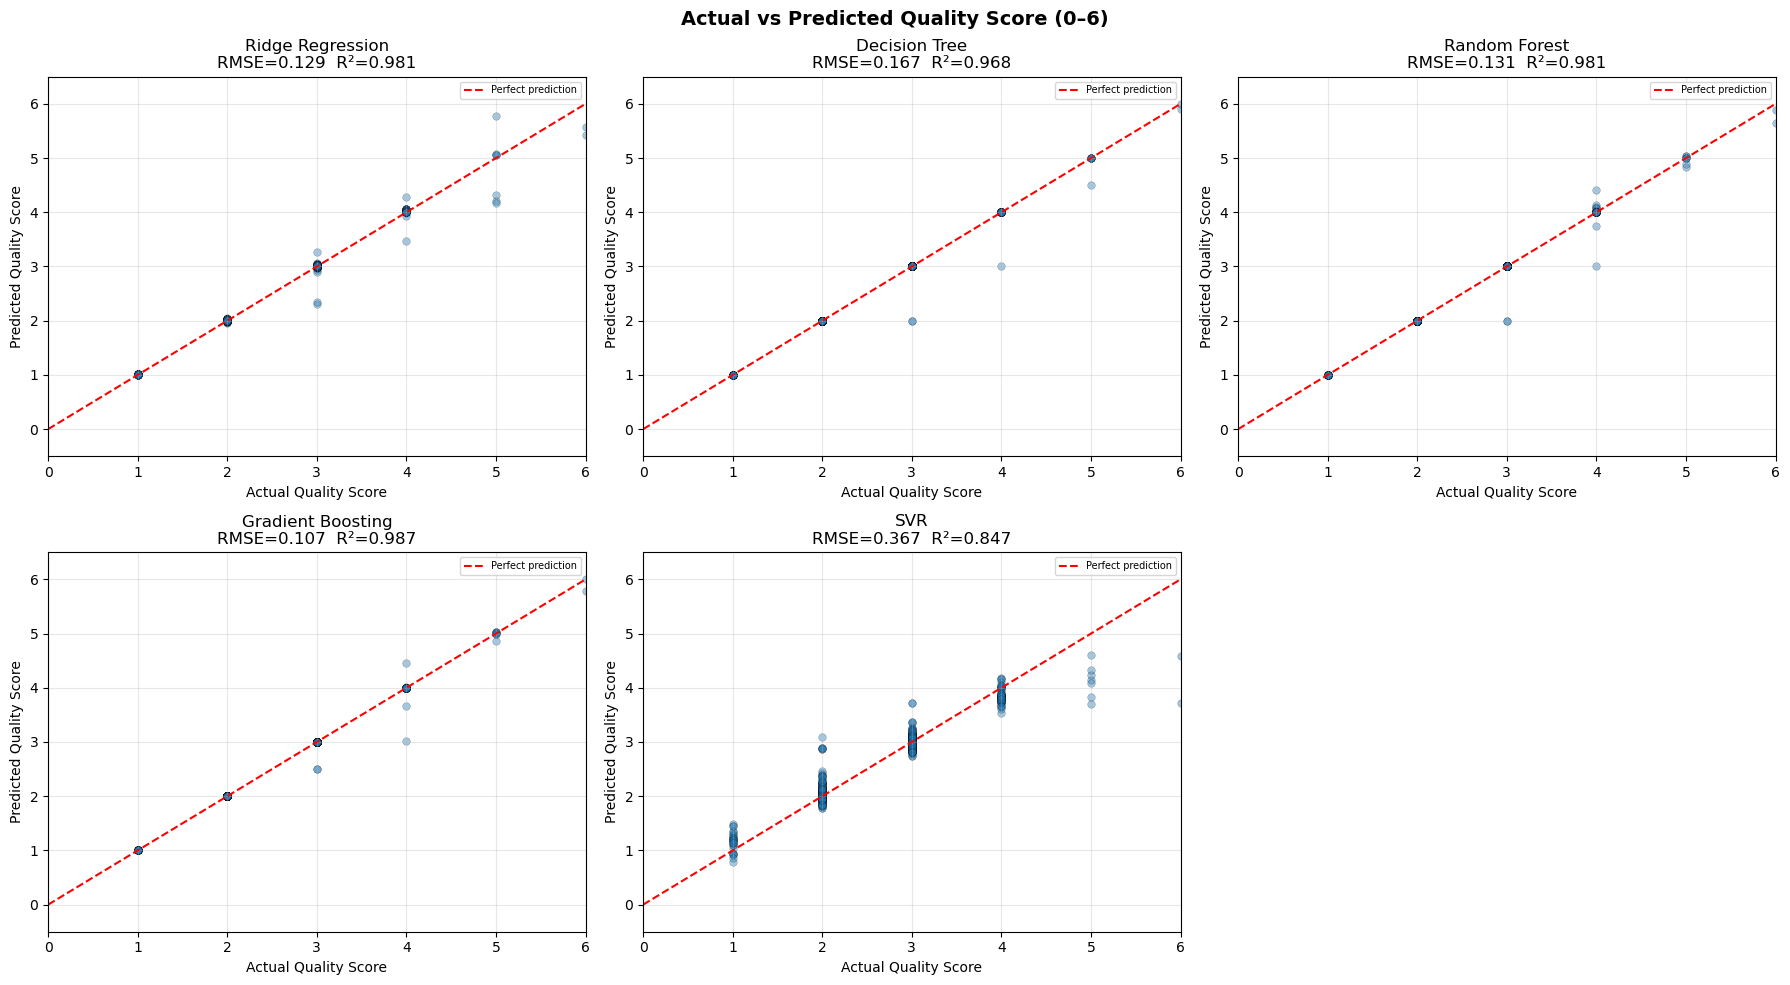

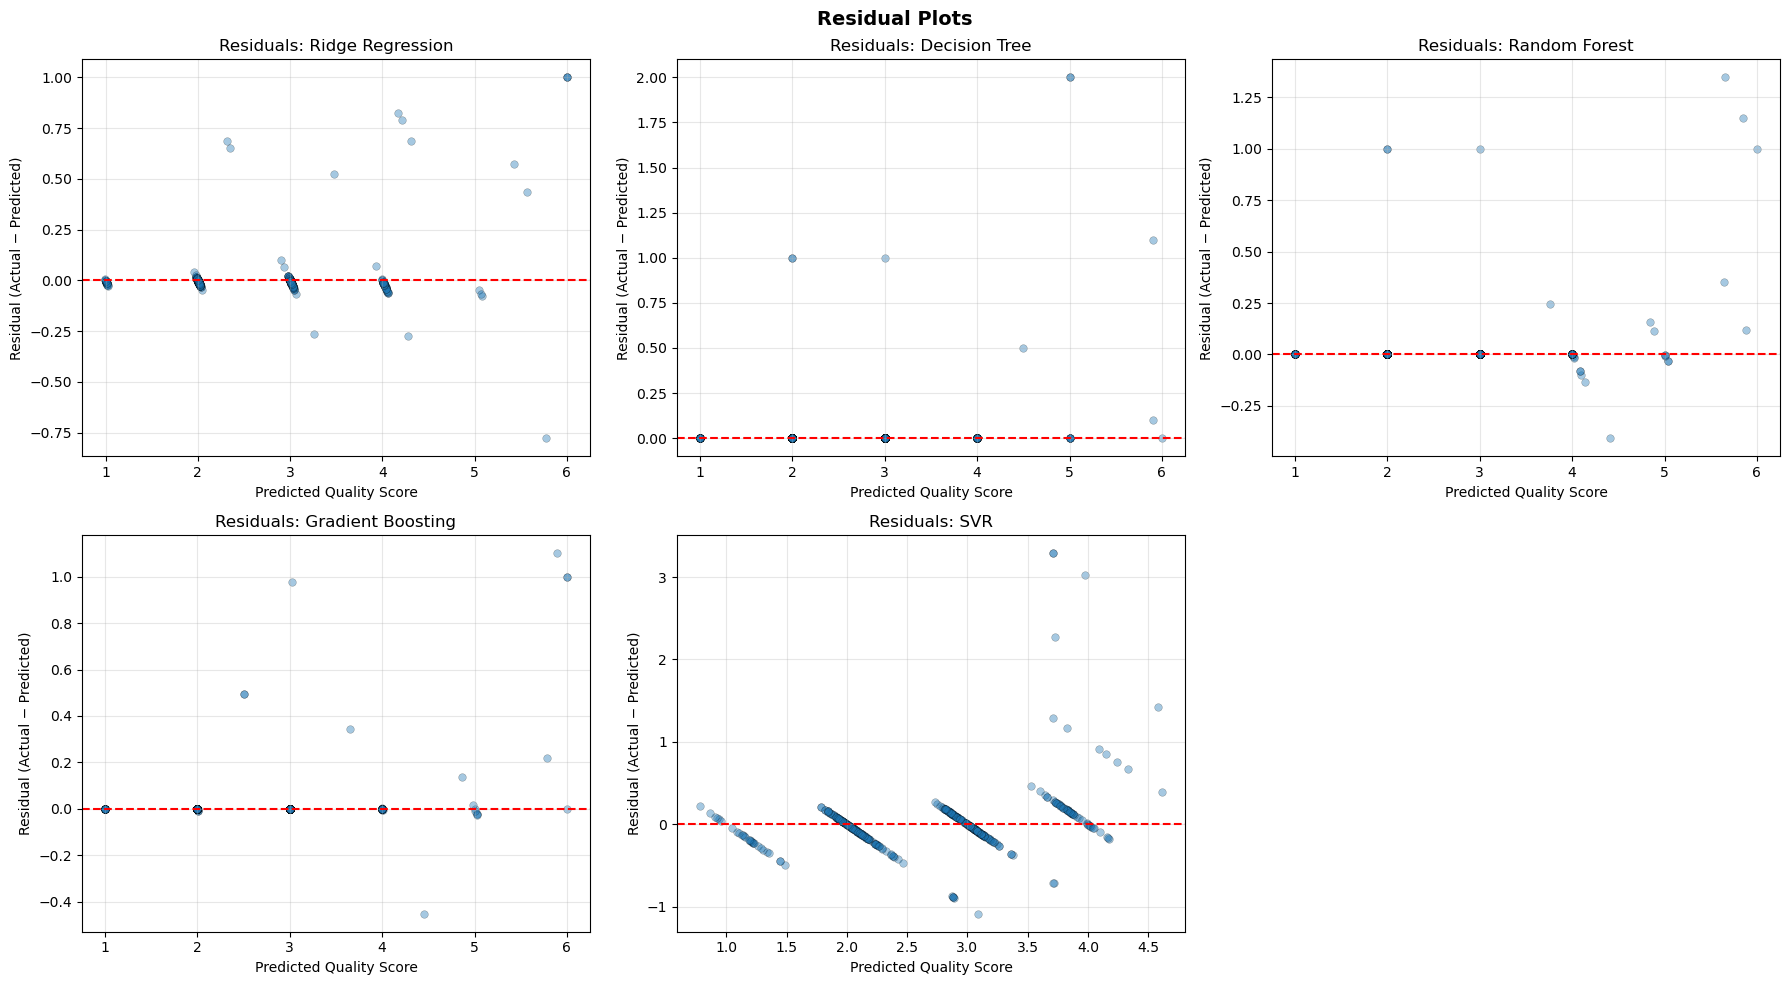

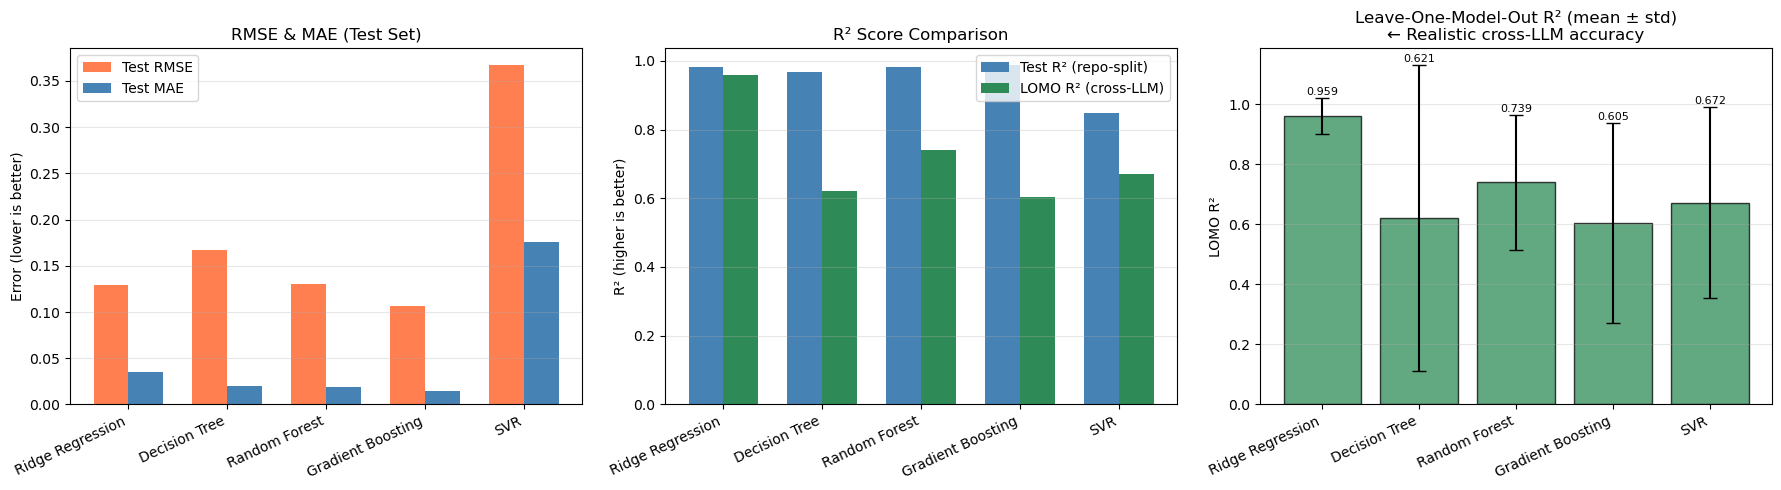

            Model  Test RMSE  Test MAE  Test R²  LOMO R²  LOMO RMSE
 Ridge Regression   0.128715  0.034665 0.981230 0.959346   0.124515
    Decision Tree   0.167399  0.019551 0.968252 0.620909   0.356345
    Random Forest   0.130510  0.018916 0.980702 0.739454   0.367718
Gradient Boosting   0.106513  0.014363 0.987146 0.604801   0.439151
              SVR   0.366975  0.176242 0.847424 0.671928   0.422143


In [10]:

model_names = list(results_summary.keys())
n_models = len(model_names)
cols = 3
rows = (n_models + cols - 1) // cols

# --- Actual vs Predicted scatter plots ---
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()
for i, (name, res) in enumerate(results_summary.items()):
    ax = axes[i]
    ax.scatter(y_test, res['y_pred'], alpha=0.4, edgecolors='k', linewidths=0.3, s=30)
    lims = [0, 6]
    ax.plot(lims, lims, 'r--', label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim([-0.5, 6.5])
    ax.set_title(f'{name}\nRMSE={res["test_rmse"]:.3f}  R²={res["test_r2"]:.3f}')
    ax.set_xlabel('Actual Quality Score')
    ax.set_ylabel('Predicted Quality Score')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Actual vs Predicted Quality Score (0–6)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Residual plots ---
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()
for i, (name, res) in enumerate(results_summary.items()):
    ax = axes[i]
    residuals = y_test.values - res['y_pred']
    ax.scatter(res['y_pred'], residuals, alpha=0.4, edgecolors='k', linewidths=0.3, s=30)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f'Residuals: {name}')
    ax.set_xlabel('Predicted Quality Score')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.grid(True, alpha=0.3)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Residual Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Metrics Comparison Bar Chart ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_df = pd.DataFrame({
    'Model':     model_names,
    'Test RMSE': [results_summary[m]['test_rmse']    for m in model_names],
    'Test MAE':  [results_summary[m]['test_mae']     for m in model_names],
    'Test R²':   [results_summary[m]['test_r2']      for m in model_names],
    'LOMO R²':   [results_summary[m]['lomo_r2_mean'] for m in model_names],
    'LOMO RMSE': [results_summary[m]['lomo_rmse_mean'] for m in model_names],
})
x = np.arange(len(model_names))
width = 0.35

axes[0].bar(x - width/2, metric_df['Test RMSE'], width, label='Test RMSE', color='coral')
axes[0].bar(x + width/2, metric_df['Test MAE'],  width, label='Test MAE',  color='steelblue')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=25, ha='right')
axes[0].set_ylabel('Error (lower is better)'); axes[0].set_title('RMSE & MAE (Test Set)')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - width/2, metric_df['Test R²'], width, label='Test R² (repo-split)', color='steelblue')
axes[1].bar(x + width/2, metric_df['LOMO R²'], width, label='LOMO R² (cross-LLM)',  color='seagreen')
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, rotation=25, ha='right')
axes[1].set_ylabel('R² (higher is better)'); axes[1].set_title('R² Score Comparison')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

lomo_r2s   = [results_summary[m]['lomo_r2_mean']   for m in model_names]
lomo_stds  = [results_summary[m]['lomo_r2_std']    for m in model_names]
axes[2].bar(model_names, lomo_r2s, yerr=lomo_stds, capsize=5,
            color='seagreen', alpha=0.75, edgecolor='black')
axes[2].set_xticklabels(model_names, rotation=25, ha='right')
axes[2].set_ylabel('LOMO R²'); axes[2].set_title('Leave-One-Model-Out R² (mean ± std)\n← Realistic cross-LLM accuracy')
axes[2].grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(lomo_r2s, lomo_stds)):
    axes[2].text(i, m + s + 0.01, f'{m:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(metric_df.to_string(index=False))


## 10. Per-LLM Model Quality Score Analysis

Predict continuous quality scores for each LLM and rank them by how much they improve code quality.


Best regression model selected: Ridge Regression
  LOMO R²:   0.9593
  Test RMSE: 0.1287
  Test R²:   0.9812

=== Per-LLM Refactoring Quality Score Ranking ===
 rank             model  actual_mean_score  actual_std_score  predicted_mean_score  predicted_std_score  total_samples
    1    gemini_3_1_pro           3.169742          0.727571              3.181765             0.734274            542
    2           gpt_oss           2.758303          0.784953              2.761867             0.787235            542
    3       claude_opus           2.760148          0.786695              2.759225             0.788993            542
    4 claude_sonnet_4_6           2.758303          0.784953              2.758499             0.787235            542
    5      gemini_flash           2.016605          1.171402              1.994654             1.106275            542


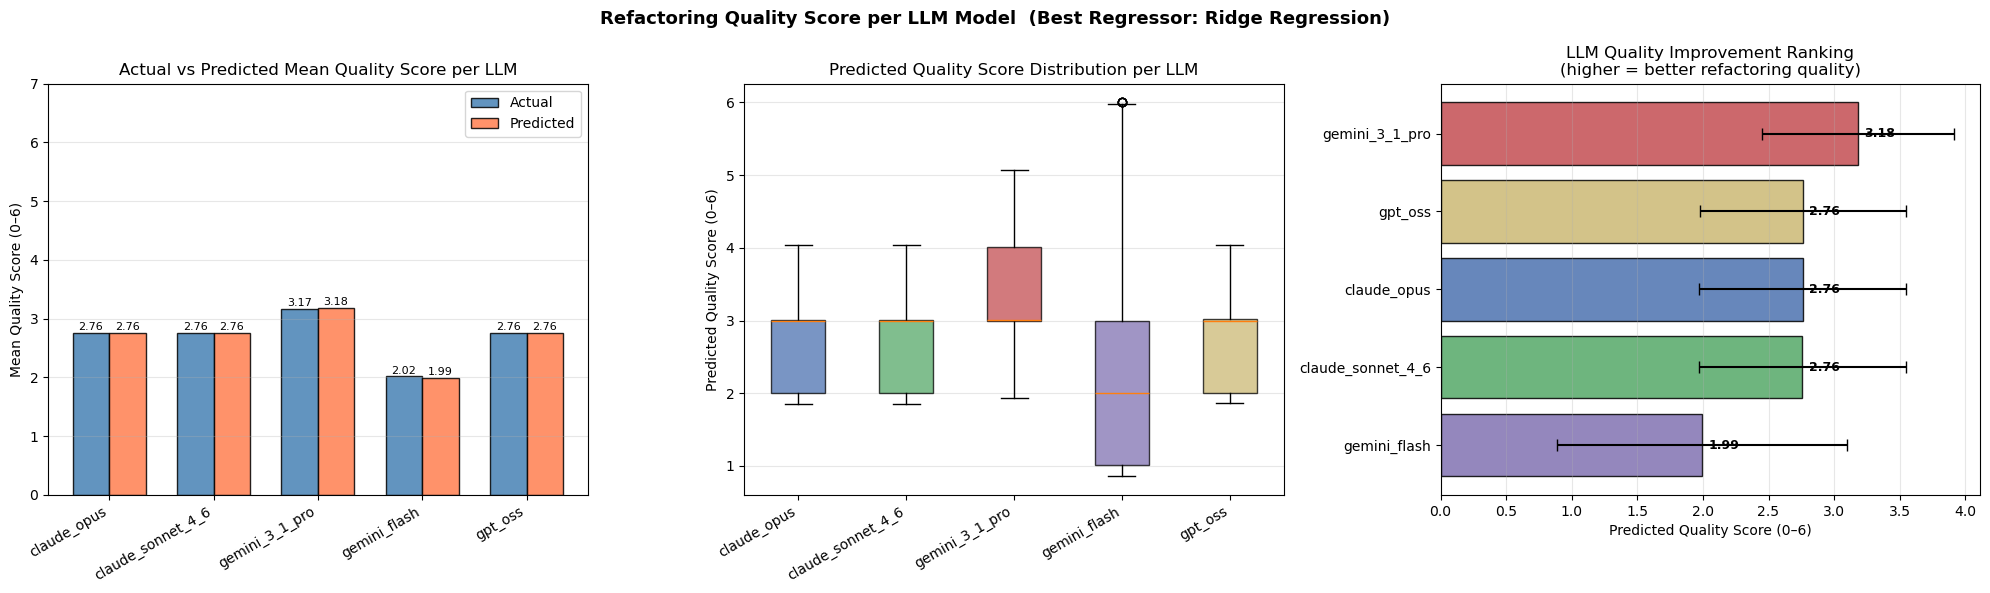

In [11]:

# Select best regression model by LOMO R² (the realistic metric)
best_ml_model_name = max(results_summary, key=lambda k: results_summary[k]['lomo_r2_mean'])
best_ml_model = results_summary[best_ml_model_name]['model']
print(f"Best regression model selected: {best_ml_model_name}")
print(f"  LOMO R²:   {results_summary[best_ml_model_name]['lomo_r2_mean']:.4f}")
print(f"  Test RMSE: {results_summary[best_ml_model_name]['test_rmse']:.4f}")
print(f"  Test R²:   {results_summary[best_ml_model_name]['test_r2']:.4f}")

# Predict continuous quality scores on full dataset
X_full = df_feat[FEATURE_COLS].fillna(0)
if best_ml_model_name in ('Ridge Regression', 'SVR'):
    X_full_use = scaler.transform(X_full)
else:
    X_full_use = X_full.values

df_feat['predicted_quality_score'] = np.clip(best_ml_model.predict(X_full_use), 0, 6)

# Per LLM model aggregation
llm_quality = df_feat.groupby('model').agg(
    actual_mean_score    = ('quality_score',           'mean'),
    actual_std_score     = ('quality_score',           'std'),
    predicted_mean_score = ('predicted_quality_score', 'mean'),
    predicted_std_score  = ('predicted_quality_score', 'std'),
    total_samples        = ('quality_score',           'count')
).reindex(MODEL_ORDER).reset_index()

# Rank by predicted mean score (higher = better quality improvement)
llm_quality['rank'] = llm_quality['predicted_mean_score'].rank(ascending=False).astype(int)
llm_quality = llm_quality.sort_values('rank')

print("\n=== Per-LLM Refactoring Quality Score Ranking ===")
print(llm_quality[['rank', 'model', 'actual_mean_score', 'actual_std_score',
                    'predicted_mean_score', 'predicted_std_score', 'total_samples']].to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Actual vs Predicted mean quality score per LLM
x = np.arange(len(MODEL_ORDER))
width = 0.35
lq = llm_quality.set_index('model').reindex(MODEL_ORDER)
axes[0].bar(x - width/2, lq['actual_mean_score'],    width, label='Actual',    color='steelblue',   edgecolor='black', alpha=0.85)
axes[0].bar(x + width/2, lq['predicted_mean_score'], width, label='Predicted', color='coral',       edgecolor='black', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
axes[0].set_ylabel('Mean Quality Score (0–6)')
axes[0].set_title('Actual vs Predicted Mean Quality Score per LLM')
axes[0].legend(); axes[0].set_ylim(0, 7)
axes[0].grid(axis='y', alpha=0.3)
for i, (a, p) in enumerate(zip(lq['actual_mean_score'], lq['predicted_mean_score'])):
    axes[0].text(i - width/2, a + 0.05, f'{a:.2f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, p + 0.05, f'{p:.2f}', ha='center', fontsize=8)

# Predicted score distribution per model (box plot)
model_data = [df_feat[df_feat['model'] == m]['predicted_quality_score'].values for m in MODEL_ORDER]
bp = axes[1].boxplot(model_data, patch_artist=True, labels=MODEL_ORDER, notch=False)
for patch, model in zip(bp['boxes'], MODEL_ORDER):
    patch.set_facecolor(MODEL_COLORS[model]); patch.set_alpha(0.75)
axes[1].set_title('Predicted Quality Score Distribution per LLM')
axes[1].set_ylabel('Predicted Quality Score (0–6)')
axes[1].set_xticklabels(MODEL_ORDER, rotation=30, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Ranking bar chart (by predicted score)
ranked = llm_quality.sort_values('predicted_mean_score', ascending=True)
colors = [MODEL_COLORS[m] for m in ranked['model']]
axes[2].barh(ranked['model'], ranked['predicted_mean_score'],
             xerr=ranked['predicted_std_score'], color=colors,
             edgecolor='black', alpha=0.85, capsize=4)
axes[2].set_xlabel('Predicted Quality Score (0–6)')
axes[2].set_title('LLM Quality Improvement Ranking\n(higher = better refactoring quality)')
axes[2].grid(axis='x', alpha=0.3)
for i, (score, model) in enumerate(zip(ranked['predicted_mean_score'], ranked['model'])):
    axes[2].text(score + 0.05, i, f'{score:.2f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle(f'Refactoring Quality Score per LLM Model  (Best Regressor: {best_ml_model_name})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/per_llm_quality_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Feature Importance Analysis

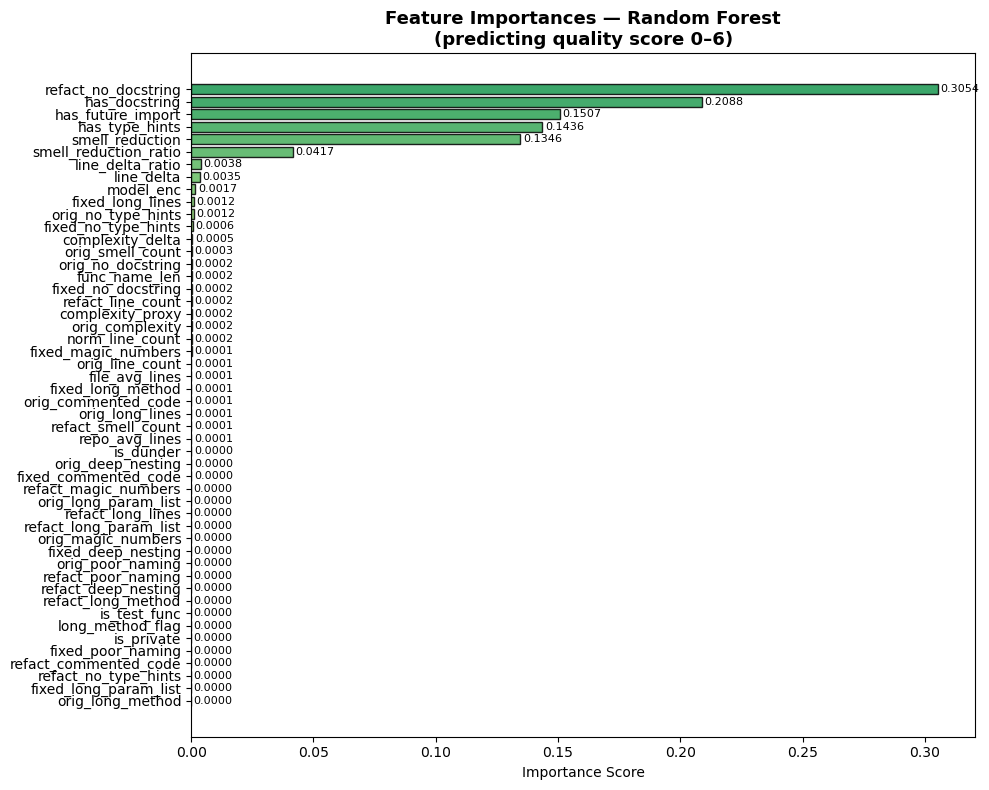


Top 5 most important features (Random Forest):
            Feature  Importance
refact_no_docstring    0.305424
      has_docstring    0.208818
  has_future_import    0.150731
     has_type_hints    0.143618
    smell_reduction    0.134616


In [12]:

# Find a tree-based model with feature_importances_
tree_based = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Decision Tree']
fi_model_name = next((m for m in tree_based if m in results_summary), None)

if fi_model_name:
    fi_model = results_summary[fi_model_name]['model']
    importances = fi_model.feature_importances_
    fi_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi_df)))
    ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'Feature Importances — {fi_model_name}\n(predicting quality score 0–6)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for i, (feat, val) in enumerate(zip(fi_df['Feature'], fi_df['Importance'])):
        ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/feature_importances.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nTop 5 most important features ({fi_model_name}):")
    print(fi_df.tail(5)[['Feature', 'Importance']].iloc[::-1].to_string(index=False))
else:
    print("No tree-based model found for feature importance.")


In [13]:

# SHAP Analysis (if available)
if SHAP_AVAILABLE and fi_model_name:
    fi_model_for_shap = results_summary[fi_model_name]['model']
    X_sample = X_test.values[:200] if len(X_test) > 200 else X_test.values

    try:
        if fi_model_name in ('Random Forest', 'Gradient Boosting', 'XGBoost', 'Decision Tree'):
            explainer   = shap.TreeExplainer(fi_model_for_shap)
            shap_values = explainer.shap_values(X_sample)

            plt.figure(figsize=(10, 7))
            shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS,
                              plot_type='bar', show=False)
            plt.title(f'SHAP Feature Importance — {fi_model_name}\n(quality score regression)')
            plt.tight_layout()
            plt.savefig(f'{PLOTS_DIR}/shap_importance.png', dpi=150, bbox_inches='tight')
            plt.show()

            plt.figure(figsize=(10, 8))
            shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS, show=False)
            plt.title(f'SHAP Summary Plot — {fi_model_name}')
            plt.tight_layout()
            plt.savefig(f'{PLOTS_DIR}/shap_summary.png', dpi=150, bbox_inches='tight')
            plt.show()
            print("SHAP analysis complete.")
    except Exception as e:
        print(f"SHAP analysis failed: {e}")
else:
    if not SHAP_AVAILABLE:
        print("SHAP not available. Install with: pip install shap")
    else:
        print("No suitable model for SHAP analysis.")


SHAP not available. Install with: pip install shap


## Summary

This notebook:
1. **Loaded** 5 LLM refactoring output datasets + original data
2. **Engineered** structural features (line counts, complexity, naming, etc.)
3. **Detected 9 code smells** in both original and refactored code:  
   `long_method`, `long_param_list`, `deep_nesting`, `magic_numbers`,  
   `no_docstring`, `no_type_hints`, `long_lines`, `commented_code`, `poor_naming`
4. **Scored** refactoring quality on a **meaningful 0–10 continuous scale** across 3 pillars:  
   Documentation (+2), Modern Python (+1), **Smell Removal (+5)**, Structural (+1), Presence (+1)
5. **Trained** 5+ regression models (Ridge, Decision Tree, Random Forest, Gradient Boosting, SVR, XGBoost)  
   on **structural + smell features** (combined feature set)
6. **Evaluated** with RMSE, MAE, R² on repo-split test set and Leave-One-Model-Out CV
7. **Ranked** the 5 LLM models by predicted quality score (0–10) to see *how much* each improves code
8. **Analyzed** feature importances and SHAP values to find the key quality drivers

### Key Insights
- Original code carries multiple smells (poor naming, no docs, long methods, etc.)
- Every LLM improves quality — the **0–10 score** shows *by how much*
- Smell removal (up to +5 pts) is the dominant quality signal — LLMs that fix more smells score higher
- `smell_reduction`, `has_docstring`, `has_type_hints`, `complexity_delta` are top predictive features
- Tree-based models (Random Forest, Gradient Boosting) typically achieve the best LOMO R²


## 12. Save Models for CLI Application

In [14]:

import joblib, pathlib

MODELS_DIR = pathlib.Path('models')
MODELS_DIR.mkdir(exist_ok=True)

# ── Save every trained regressor ──────────────────────────────────────────────
for name, res in results_summary.items():
    safe = name.lower().replace(' ', '_')
    joblib.dump(res['model'], MODELS_DIR / f'quality_{safe}.pkl')
    print(f"  Saved quality regressor: models/quality_{safe}.pkl")

# ── Save scaler, label encoder, feature metadata ─────────────────────────────
joblib.dump(scaler,   MODELS_DIR / 'quality_scaler.pkl')
joblib.dump(le_model, MODELS_DIR / 'quality_label_encoder.pkl')

# Save dataset-level stats the CLI needs for normalisation
stats = {
    'global_max_lines':  float(global_max),
    'repo_avg_lines':    df_feat.groupby('Repository Link')['orig_line_count'].mean().to_dict(),
    'file_avg_lines':    df_feat.groupby('File name')['orig_line_count'].mean().to_dict(),
    'global_repo_mean':  float(df_feat['repo_avg_lines'].mean()),
    'global_file_mean':  float(df_feat['file_avg_lines'].mean()),
    'feature_cols':      FEATURE_COLS,
    'target':            TARGET_COL,       # 'quality_score' (continuous 0-6)
    'model_order':       MODEL_ORDER,
    'scaled_models':     ['Ridge Regression', 'SVR'],
}
joblib.dump(stats, MODELS_DIR / 'quality_stats.pkl')
print("  Saved quality_scaler.pkl, quality_label_encoder.pkl, quality_stats.pkl")

# ── Save the best model name for easy CLI loading ─────────────────────────────
best_name = max(results_summary, key=lambda k: results_summary[k]['lomo_r2_mean'])
joblib.dump({'best_model': best_name,
             'all_models': list(results_summary.keys()),
             'task':       'regression',
             'score_range': [0, 6]},
            MODELS_DIR / 'quality_meta.pkl')
print(f"\nBest quality regressor: {best_name}")
print(f"  LOMO R²:   {results_summary[best_name]['lomo_r2_mean']:.4f}")
print(f"  Test RMSE: {results_summary[best_name]['test_rmse']:.4f}")
print(f"All models saved to: {MODELS_DIR.resolve()}/")


  Saved quality regressor: models/quality_ridge_regression.pkl
  Saved quality regressor: models/quality_decision_tree.pkl
  Saved quality regressor: models/quality_random_forest.pkl
  Saved quality regressor: models/quality_gradient_boosting.pkl
  Saved quality regressor: models/quality_svr.pkl
  Saved quality_scaler.pkl, quality_label_encoder.pkl, quality_stats.pkl

Best quality regressor: Ridge Regression
  LOMO R²:   0.9593
  Test RMSE: 0.1287
All models saved to: C:\Users\prart\OneDrive\Desktop\Research_Project\code\codeworks\models/
